# Manual implementation of radon transform

We have seen how the radon transform is the "line integral" of an image along multiple angles.
Try to implement it manually using
* scipy.ndimage.rotate
* np.sum

Compare the results with skimage.transform.radon

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi

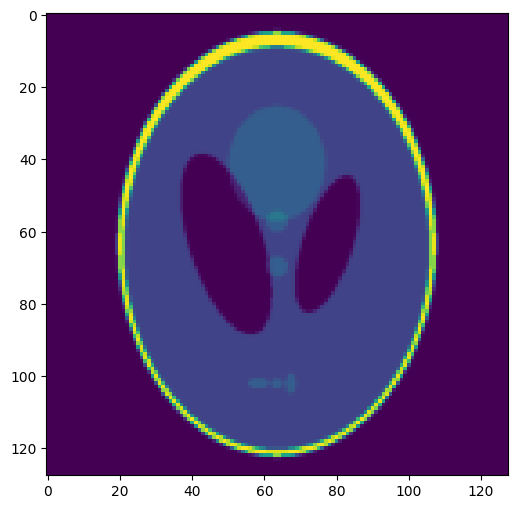

In [ ]:
import skimage.data
from skimage.transform import radon, iradon

nPix = 128
plt.figure(figsize=(6,6))
immFull = skimage.data.shepp_logan_phantom()
imm = skimage.transform.resize(immFull,(nPix,nPix),anti_aliasing=True)
plt.imshow(imm)

## 1. Implement the forward projection

Think how it should work. As in the other notebook, you will need to define a number of angles.
Preallocate a sinogram vector: which dimensions does it have? (How should you set the "reshape" parameter of rotate?)

`scipy.ndimage.rotate(..., reshape=True)` is important: `reshape=True` enlarges the output array so nothing gets clipped off when rotated. `reshape=False` clips the corners, losing information.

In [9]:
def manual_radon(image: np.ndarray, theta: np.ndarray) -> np.ndarray:
    """
    Parallel-beam Radon transform via rotate-and-sum.

    Parameters
    ----------
    image : 2D array
    theta : 1D array of projection angles in degrees

    Returns
    -------
    sinogram : 2D array, shape (detector_length, len(theta))
    """
    # Find output shape by doing one test rotation with reshape=True
    # (all angles give the same output shape when reshape=True)
    rotated_sample = ndi.rotate(image, angle=0, reshape=True)
    detector_length = rotated_sample.shape[0]

    sinogram = np.zeros((detector_length, len(theta)))

    for i, angle in enumerate(theta):
        # Rotate image by -angle so that projection direction becomes vertical.
        # Sign convention: skimage's radon rotates by -theta; match that.
        rotated = ndi.rotate(image, angle=-angle, reshape=True, order=1)
        sinogram[:, i] = rotated.sum(axis=0)

    return sinogram

## 2. Implement the transposedvoperation: backprojection
In a backprojection you add to every pixel that sits along a projection line the sinogram value. Also this can be done using only ndi.rotate and a sum (you'll likely need to broadcast along one axis)


In [12]:
def manual_backprojection(sinogram: np.ndarray, theta: np.ndarray, output_shape: tuple[int, int] | None = None) -> np.ndarray:
    """
    Simple (unfiltered) back-projection via broadcast-and-rotate.

    Parameters
    ----------
    sinogram : 2D array, shape (detector_length, n_angles)
    theta : 1D array of angles (degrees) — must match those used in radon
    output_shape : final image shape; if None, uses detector_length square

    Returns
    -------
    reconstruction : 2D array (unfiltered back-projection)
    """
    detector_length, n_angles = sinogram.shape
    assert n_angles == len(theta)

    # Work in a square canvas sized to the detector length
    canvas_size = detector_length
    reconstruction = np.zeros((canvas_size, canvas_size))

    for i, angle in enumerate(theta):
        # 1. Take one projection column
        projection = sinogram[:, i]                       # shape (L,)

        # 2. Broadcast it into a 2D image: every row = the projection
        #    shape (L, L) — smeared along axis 0
        smeared = np.broadcast_to(projection[np.newaxis, :], (canvas_size, canvas_size))

        # 3. Rotate back by +angle (opposite sign from forward projection)
        rotated_back = ndi.rotate(smeared, angle=angle, reshape=False, order=1)

        # 4. Accumulate
        reconstruction += rotated_back

    # Normalize by number of angles (so the result is an average, not a sum)
    reconstruction *= np.pi / (2 * n_angles)

    # Optional: crop back to the original image shape
    if output_shape is not None:
        H, W = output_shape
        start_y = (canvas_size - H) // 2
        start_x = (canvas_size - W) // 2
        reconstruction = reconstruction[start_y:start_y + H, start_x:start_x + W]

    return reconstruction

# 3. Implement the filter for a full reconstruction!

These 2 approaches are (in an ideal world) equivalent:
1. filter the sinogram -> backproject
2. backproject -> filter the image

Filtering is a convolution operation, which is a multiplication in Fourier space.
Try the following:
1. Define an empty image of the same size of the image you're working with. Set the central pixel to 1.
2. Apply the forward and back projection to it
3. Take the fourier transform of this and look at it! It should look like a hyperbole (BTW, how do you expect the real and imaginary part to be). The inverse (literally $1/x$ pixelwise) is what you need to filter for
4. Backproject the sinogram of the image you want to recontruct and take its fourier transform
5. Multiply it by the frequency spectrum of point 3
6. Take the inverse fourier transform. Up to numerical errors, it should work

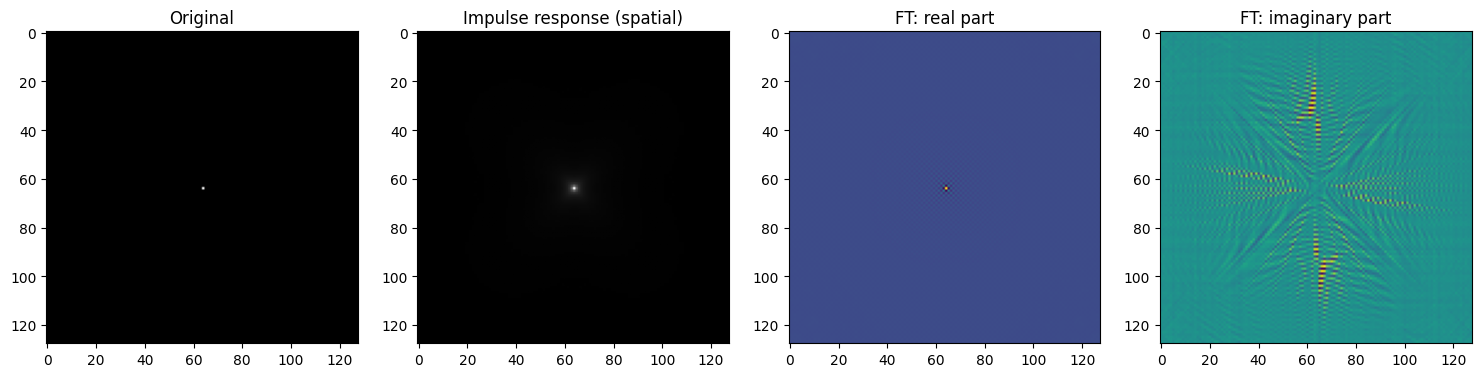

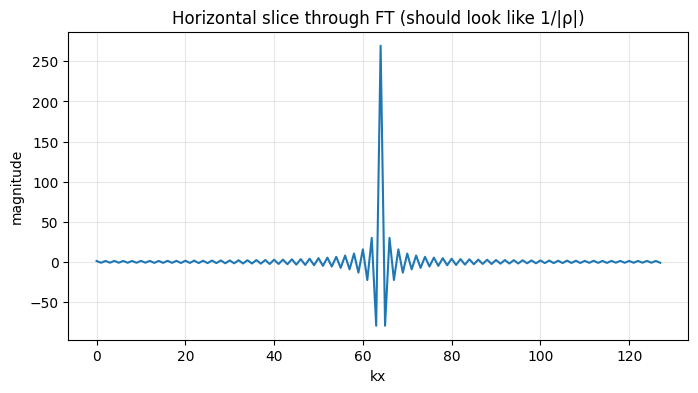

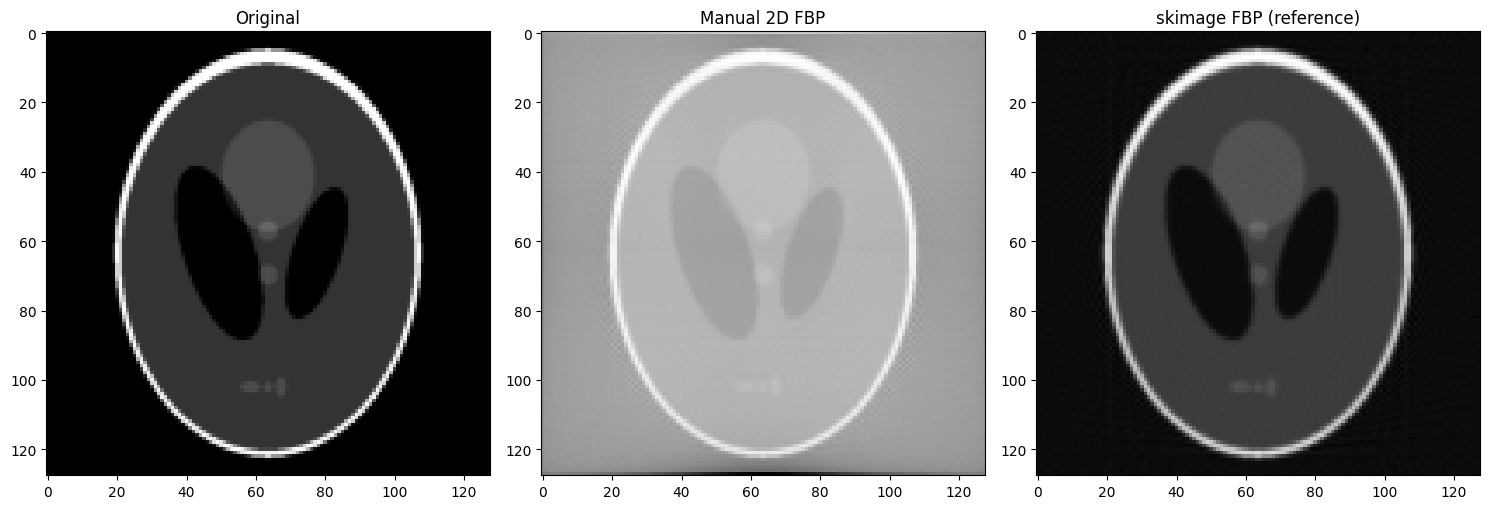

In [15]:
# ---------- Step 1: delta image ----------
delta_img = np.zeros_like(imm)
cy, cx = delta_img.shape[0] // 2, delta_img.shape[1] // 2
delta_img[cy, cx] = 1.0

theta = np.arange(0, 180, 1)

# ---------- Step 2: forward then back projection ----------
sino_delta = radon(delta_img, theta=theta, circle=False)
impulse    = iradon(sino_delta, theta=theta, circle=False, filter_name=None)
# ^ this is (R^T R) δ — the impulse response

# ---------- Step 3: FT of the impulse response ----------
FT_impulse = np.fft.fftshift(np.fft.fft2(impulse))

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(delta_img, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(impulse, cmap="gray")
axes[1].set_title("Impulse response (spatial)")
axes[2].imshow(np.real(FT_impulse), cmap="viridis")
axes[2].set_title("FT: real part")
axes[3].imshow(np.imag(FT_impulse), cmap="viridis")
axes[3].set_title("FT: imaginary part")
plt.tight_layout(); plt.show()

# 1D slice through the FT — should look like 1/|ρ|
plt.figure(figsize=(8, 4))
row = np.real(FT_impulse[FT_impulse.shape[0] // 2, :])
plt.plot(row)
plt.title("Horizontal slice through FT (should look like 1/|ρ|)")
plt.xlabel("kx"); plt.ylabel("magnitude")
plt.grid(alpha=0.3); plt.show()

# ---------- Step 4: backproject the real image's sinogram ----------
sino_img = radon(imm, theta=theta, circle=False)
bp_img   = iradon(sino_img, theta=theta, circle=False, filter_name=None)
FT_bp    = np.fft.fftshift(np.fft.fft2(bp_img))

# ---------- Step 5: the filter is 1 / FT(impulse) ----------
# Handle the DC divergence by thresholding
eps = 1e-6 * np.abs(FT_impulse).max()
filter_2d = 1.0 / (np.abs(FT_impulse) + eps)   # magnitude is enough since FT is real

# ---------- Step 6: filter and inverse FT ----------
reconstructed_FT = FT_bp * filter_2d
reconstructed    = np.real(np.fft.ifft2(np.fft.ifftshift(reconstructed_FT)))

# ---------- Compare ----------
ref = iradon(sino_img, theta=theta, circle=False)   # skimage FBP (ramp, default)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imm, cmap="gray");            axes[0].set_title("Original")
axes[1].imshow(reconstructed, cmap="gray");  axes[1].set_title("Manual 2D FBP")
axes[2].imshow(ref, cmap="gray");            axes[2].set_title("skimage FBP (reference)")
plt.tight_layout(); plt.show()